# Module 2 - Data preparation and Baseline Model 

This notebook builds the Module 2 dataset — merging the 42-feature matrix with the binary Milieuschutz label (milieu_majoritaet) — and establishes a logistic regression as the baseline classifier for identifying areas that resemble protected ones. 

Preprocessing (KNN imputation, log-transformation of skewed features, and standardization) is fitted fold-wise inside the cross-validation loop rather than on the full dataset, so that no information from the validation areas leaks into training. 

Cross-validation uses GroupKFold grouped by Bezirk because neighbouring PLRs within a district are spatially and administratively correlated, and Milieuschutz is designated at the Bezirk level; grouping this way prevents the model from memorising district-specific patterns and forces it to generalise across districts, giving a spatially honest performance estimate. 

The label is treated as positive-unlabeled (PU) rather than a clean positive/negative split: a PLR marked 1 is confirmed protected, but a 0 only means "not currently designated" — it may well be gentrifying and simply not yet (or never) protected, since designation arrives late and each Bezirk decides independently. This framing is central to the project, because it reframes the model's confident false positives — undesignated areas that look strongly designated — not as errors but as the early-warning watchlist the platform is built to surface.

In [ ]:
#load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from Dataprep import preprocess_fit_transform



In [2]:
#Load the features 
X_df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})

#load the label for Module 2
labels = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#join left on plr_id 
df = X_df.merge(labels[["plr_id", "milieu_majoritaet"]], on="plr_id", how="left")


In [3]:
#sanity check
df.shape


(527, 46)

In [4]:
#sanity check 2 
df.columns


Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_average_household_size_2024',
       'soc_average_household_size_change_2021_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_unemployment_share_change_2020_2024',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_

In [5]:
#sanity check label

LABEL = "milieu_majoritaet"
assert df[LABEL].notna().all(), "Label enthält NaN — unerwartet."
assert set(df[LABEL].unique()) <= {0, 1}, "Label ist nicht binär 0/1."
print(df[LABEL].value_counts(), "\n")

milieu_majoritaet
0    418
1    109
Name: count, dtype: int64 



### Amount of positives doesn't shrink due to the drop 

All dropped PLRs aren't protected. Therefore, the amount of 109 observations of protected PLRs remains and to find 20.7% of the cases is the baseline. 

In [6]:
#define columns 
ID_COLS = ["plr_id", "plr_name", "bez"]   
GROUP_COL = "bez"

#Leakage guard: milieu_anteil is the continuous share the LABEL is derived from (>50% -> milieu_majoritaet)
#It must never enter the features. Not currently merged in, but excluded defensively; the assert below is the actual safeguard
LEAKAGE_COLS = ["milieu_anteil"]

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [LABEL] + LEAKAGE_COLS
]
assert not any("milieu" in c for c in feature_cols), \
    "Label-abgeleitete Spalte im Feature-Set — Leakage!"

## 1 Checks of variables for log transformation 

In [7]:
#calculate skew to define the variables for log-transformation 
skew = df[feature_cols].skew().sort_values(ascending=False)
print("Skewness per feature (descending):\n")
print(skew.to_string())

#Rule of thumb: |skew| > 1 is clearly skewed -> variable for log-transformation 
#log only works for non-negative variables; exclude shares/trends as needed
log_candidates = skew[skew.abs() > 1].index.tolist()
print("\nCandidates (|skew| > 1):", log_candidates)



Skewness per feature (descending):

com_tourism_share_level_2026                                    11.429474
re_dichte_all                                                    3.822843
soc_internal_migration_volume_rate_2025                          3.763845
re_neubau_share                                                  3.556610
com_n_gastro                                                     2.963353
com_share_max_2y_slope                                           2.846477
soc_internal_migration_volume_rate_change_2021_2025              2.754792
com_share_solo_slope                                             2.332406
re_leerstandsquote                                               2.041133
re_brw_niveau                                                    1.924704
com_share_10plus_level_2026                                      1.828611
soc_single_parent_household_share_2024                           1.478141
soc_average_household_size_change_2021_2024                      1.261005
co

In [8]:
#check whether the minimum values of the proposed variables for log transformation are all positive
proposed_log = [
    "com_tourism_share_level_2026", 
    "re_dichte_all", 
    "soc_internal_migration_volume_rate_2025", 
    're_neubau_share', 
    'com_n_gastro', 
    'com_share_max_2y_slope', 
    'soc_internal_migration_volume_rate_change_2021_2025', 
    'com_share_solo_slope', 
    're_leerstandsquote', 
    're_brw_niveau', 
    'com_share_10plus_level_2026', 
    'soc_single_parent_household_share_2024', 
    'soc_average_household_size_change_2021_2024', 
    'com_median_age_slope', 
    'com_share_10plus_slope', 
    'soc_single_person_hh_share_change_2021_2024', 
    'com_gastro_share_slope', 
    'soc_internal_net_migration_rate_change_2021_2025', 
    'soc_internal_net_migration_rate_2025', 
    'com_entry_rate_slope']

mins = df[proposed_log].min()
print("Minimum per proposed log feature:\n")
print(mins.to_string())

# Any negative minimum means log1p is invalid for that column -> drop it
invalid = mins[mins < 0].index.tolist()
print("\nNegative minimum (must NOT log):", invalid)

LOG_COLS = [c for c in proposed_log if c not in invalid]
print("\nFinal LOG_COLS:", LOG_COLS)

Minimum per proposed log feature:

com_tourism_share_level_2026                             0.000000
re_dichte_all                                            0.000000
soc_internal_migration_volume_rate_2025                  0.071000
re_neubau_share                                          0.000000
com_n_gastro                                             0.000000
com_share_max_2y_slope                                  -0.079085
soc_internal_migration_volume_rate_change_2021_2025     -0.281000
com_share_solo_slope                                    -0.030888
re_leerstandsquote                                       0.361197
re_brw_niveau                                          256.493697
com_share_10plus_level_2026                              0.000000
soc_single_parent_household_share_2024                   0.022000
soc_average_household_size_change_2021_2024             -0.200000
com_median_age_slope                                    -2.420077
com_share_10plus_slope                   

In [9]:
#confirmed, therefore log transform the proposed ones 

LOG_COLS = [
    "com_tourism_share_level_2026",
    "re_dichte_all",
    "soc_internal_migration_volume_rate_2025",
    "re_neubau_share",
    "com_n_gastro",
    "re_leerstandsquote",
    "re_brw_niveau",
    "com_share_10plus_level_2026",
    "soc_single_parent_household_share_2024",
]


LOG_COLS = [c for c in LOG_COLS if c in feature_cols]

print(f"\n{len(feature_cols)} features, of which {len(LOG_COLS)} were log transformed: {LOG_COLS}")



42 features, of which 9 were log transformed: ['com_tourism_share_level_2026', 're_dichte_all', 'soc_internal_migration_volume_rate_2025', 're_neubau_share', 'com_n_gastro', 're_leerstandsquote', 're_brw_niveau', 'com_share_10plus_level_2026', 'soc_single_parent_household_share_2024']


## 2 Prepare features, target and groups 


In [10]:
#saveguard plr_id as string with 8 digits 
df["plr_id"] = df["plr_id"].astype(str).str.zfill(8)

X = df[feature_cols].copy()
y = df[LABEL].astype(int).to_numpy()           
groups = df[GROUP_COL].to_numpy()
plr_ids = df["plr_id"].to_numpy()

# Sanity-Checks 
assert len(X) == len(y) == len(groups) == len(plr_ids)
assert df["plr_id"].is_unique, "plr_id not unambiguous!"
n_pos = int(y.sum())
print(f"\nPositive: {n_pos} | Negative: {len(y) - n_pos} | positive rate: {n_pos/len(y):.1%}")



Positive: 109 | Negative: 418 | positive rate: 20.7%


## 3 Out of Fold loop and Baseline Model (LogReg)

In [11]:
#Per fold: preprocessing via preprocess_fit_transform from Dataprep.py (fit impute + log + scale on TRAIN only, apply to VAL)

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

#build an OOF-Array to get one probability per PLR
oof_prob = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y[train_idx]

    #fold-wise preprocessing (leakage-safe): fit on train, apply to both
    X_train_prep, X_val_prep = preprocess_fit_transform(
        X_train, X_val, feature_cols, LOG_COLS, scale=True
    )

    #LogReg as baseline model: fit on train, predict_proba for val
    model = LogisticRegression(class_weight="balanced", max_iter=1000)
    model.fit(X_train_prep, y_train)
    oof_prob[val_idx] = model.predict_proba(X_val_prep)[:, 1]

    #fold diagnosis
    fold_ap = average_precision_score(y[val_idx], oof_prob[val_idx])
    print(f"Fold {fold}: n_val={len(val_idx):3d} | "
          f"Bezirke={np.unique(groups[val_idx])} | AUC-PR={fold_ap:.3f}")

#Check for full OOF-coverage
assert not np.isnan(oof_prob).any(), "Not every PLR has an OOF prediction"

Fold 1: n_val= 96 | Bezirke=['03 - Pankow' '10 - Marzahn-Hellersdorf'] | AUC-PR=0.609
Fold 2: n_val= 92 | Bezirke=['04 - Charlottenburg-Wilmersdorf' '11 - Lichtenberg'] | AUC-PR=0.329
Fold 3: n_val=125 | Bezirke=['01 - Mitte' '09 - Treptow-Köpenick' '12 - Reinickendorf'] | AUC-PR=0.571
Fold 4: n_val= 91 | Bezirke=['05 - Spandau' '07 - Tempelhof-Schöneberg'] | AUC-PR=0.791
Fold 5: n_val=123 | Bezirke=['02 - Friedrichshain-Kreuzberg' '06 - Steglitz-Zehlendorf'
 '08 - Neukölln'] | AUC-PR=0.877


In [12]:
oof_df = pd.DataFrame({
    "plr_id": plr_ids,
    "y_true": y,
    "oof_prob": oof_prob,
})

overall_ap = average_precision_score(y, oof_prob)
baseline_ap = y.mean()   
print(f"\nGesamt AUC-PR: {overall_ap:.3f}  (Baseline = {baseline_ap:.3f})")

oof_df.to_csv("../../models/M_oof_logreg.csv", index=False) 



Gesamt AUC-PR: 0.627  (Baseline = 0.207)


## Result Discussion 

- AUC-PR 0.627, fold range 0.33–0.88 across districts
- fold range as the honesty caveat that doubles as a finding (districts gentrify unevenly)

The model identifies Milieuschutz patterns far above chance: pooled AUC-PR 0.627
vs. a 0.207 baseline. Because the GroupKFold is grouped by Bezirk, no district
appears in both training and validation, so this is a spatially honest estimate
rather than an inflated one.

Performance varies strongly across folds (0.33–0.88), and the variation is
itself informative. The model generalizes worst on the Charlottenburg-Wilmersdorf
/ Lichtenberg fold, where the designation logic departs most from the inner-city
template — established western affluence and an eastern post-reunification
trajectory respectively. It performs best on folds containing the classic
inner-city gentrification cases (Friedrichshain-Kreuzberg, Neukölln). Rather than
treating the spread as noise, it is better read as evidence that districts
gentrify by different mechanisms — a substantive point the model surfaces rather
than hides.



In [13]:
#LogReg coefficients — magnitude + cross-fold stability
#preprocessing via preprocess_fit_transform from Dataprep.py, identical to the OOF loop

#Per-fold coefficients for stability
fold_coefs = []
for train_idx, val_idx in gkf.split(X, y, groups):
    Xtr_s, _ = preprocess_fit_transform(
        X.iloc[train_idx], X.iloc[val_idx], feature_cols, LOG_COLS, scale=True
    )
    m = LogisticRegression(class_weight="balanced", max_iter=1000)
    m.fit(Xtr_s, y[train_idx])
    fold_coefs.append(m.coef_[0])

fold_coefs = np.array(fold_coefs)  # shape (5, n_features)

#One model refit on all rows for the headline ranking
X_all_s, _ = preprocess_fit_transform(X, X, feature_cols, LOG_COLS, scale=True)
m_all = LogisticRegression(class_weight="balanced", max_iter=1000)
m_all.fit(X_all_s, y)

#results table: full-data coef as headline, mean + spread across folds for stability
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coef_all": m_all.coef_[0],
    "coef_mean_fold": fold_coefs.mean(0),
    "coef_std_fold": fold_coefs.std(0),
})
coef_table["abs_coef"] = coef_table["coef_all"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)

#Flag unstable signs: large effect but flips direction across folds
coef_table["sign_stable"] = (
    np.sign(coef_table["coef_mean_fold"]) == np.sign(coef_table["coef_all"])
) & (coef_table["coef_std_fold"] < coef_table["abs_coef"])

print(coef_table.to_string(index=False))

                                                     feature  coef_all  coef_mean_fold  coef_std_fold  abs_coef  sign_stable
                                             re_neubau_share -0.933569       -0.938880       0.213300  0.933569         True
                        soc_young_to_middle_adult_share_2025  0.880653        0.873061       0.295826  0.880653         True
                                               re_brw_niveau  0.873674        0.853838       0.181109  0.873674         True
                     soc_internal_migration_volume_rate_2025 -0.862412       -0.702294       0.217102  0.862412         True
                             soc_transfer_benefit_share_2024  0.793909        0.905483       0.348208  0.793909         True
            soc_young_to_middle_adult_share_change_2021_2025 -0.673518       -0.651958       0.140771  0.673518         True
                                                com_n_gastro  0.577187        0.620534       0.411678  0.577187         True


# Explanation (to be deleted later, when results are interpreted) 

coef_all is your headline number per feature. Positive = pushes a PLR toward "looks like Milieuschutz"; negative = away. Because features are standardized, |coef| is comparable across features, so the top of the sorted table is your most influential variables.
coef_std_fold is the stability check. A feature with a big coef_all but a coef_std_fold of similar size is fragile — it's doing different things in different districts, so don't over-claim it.
sign_stable flags the ones you can describe confidently: large, and pointing the same direction in the full model and on average across folds.

TWO CAVEATS

First, sign can be counterintuitive under correlation. If two features are correlated (your Spearman check kept everything under |0.8| cross-dimension, so this is limited, but within-dimension pairs can still be moderate), LogReg can split the effect between them and even flip a sign. So read the top features as a set, not each in isolation — especially within the real-estate block where rent level, BRW level and Altbau share are related.
Second — and this connects to your whole framing — these coefficients describe what predicts designation, not what causes gentrification. A high positive coefficient on, say, Altbau share means "designated areas tend to have more Altbau," which is partly because Milieuschutz policy itself targets Altbau-heavy areas. So phrase it as "associated with Milieuschutz designation," not "drives gentrification." That distinction keeps the claim defensible.

WHERE TO PUT THE FOCUS NEXT

Performance: pooled AUC-PR + fold range + LogReg-vs-XGBoost. Don't rabbit-hole on hyperparameter tuning — untuned-but-honest is a fine capstone story, and tuning under GroupKFold is fiddly.
Feature analysis: top features by magnitude, stability flag, and the per-dimension rollup. Don't go deep on SHAP interaction plots now — one clean importance view per model is enough; fancy SHAP is next-week polish if time allows.
False positives: the ranked list, count, spatial pattern, and the milieu_anteil check. This is your centerpiece, so it earns the most depth — but it depends on XGBoost and Cleanlab being done first.

--> storyline: The model learns what Milieuschutz designation looks like (performance), the three dimensions tell us which signals define that pattern (features), and where the model confidently disagrees with the current designation map, we get an early-warning watchlist (false positives). 

In [17]:
#Per-dimension contribution: how much signal does each block carry?
coef_table["dim"] = coef_table["feature"].str[:3]  # 're_', 'soc', 'com'

dim_summary = coef_table.groupby("dim").agg(
    n_features=("feature", "count"),
    mean_abs_coef=("abs_coef", "mean"),
    sum_abs_coef=("abs_coef", "sum"),
    n_in_top10=("feature", lambda s: s.head(10).isin(
        coef_table.head(10)["feature"]).sum()),
).sort_values("mean_abs_coef", ascending=False)

#How many of the top 10 features come from each dimension?
print(dim_summary.to_string())


     n_features  mean_abs_coef  sum_abs_coef  n_in_top10
dim                                                     
re_           8       0.458868      3.670945           3
soc          15       0.428582      6.428736           5
com          19       0.214983      4.084669           2


## Result Discussion

Designated areas are defined less by a single dimension than by a consistent social-and-real-estate signature. On the social side, they show a higher share
of young-to-middle adults and elevated transfer-benefit dependency, combined
with low residential turnover. Internal migration volume is among the strongest
negative predictors: a picture of an established, comparatively stable
population rather than a high-churn one. On the real-estate side, high land-value
levels (BRW niveau) mark designated areas, while new construction is the single
strongest predictor pointing the other way. 

Social features dominate the top of the ranking by count, but real-estate features carry the highest average magnitude per feature and include the strongest individual signal. Whether this signature is a cause of designation, a criterion for it, or a consequence of prior  gentrification cannot be determined from this cross-sectional model.

The positive coefficient on transfer-benefit share (+0.79) is the most counterintuitive result in the table. Naive gentrification intuition says "richer area." Instead, designated areas show more welfare dependency, not less. That points away from "the population has already turned over (gentrified)" and toward "Milieuschutz is placed where a vulnerable population still exists and is worth protecting" — i.e. the policy targets areas at risk before full transformation, not after. This is much closer to the project's early-warning
thesis than an "already changed" reading.

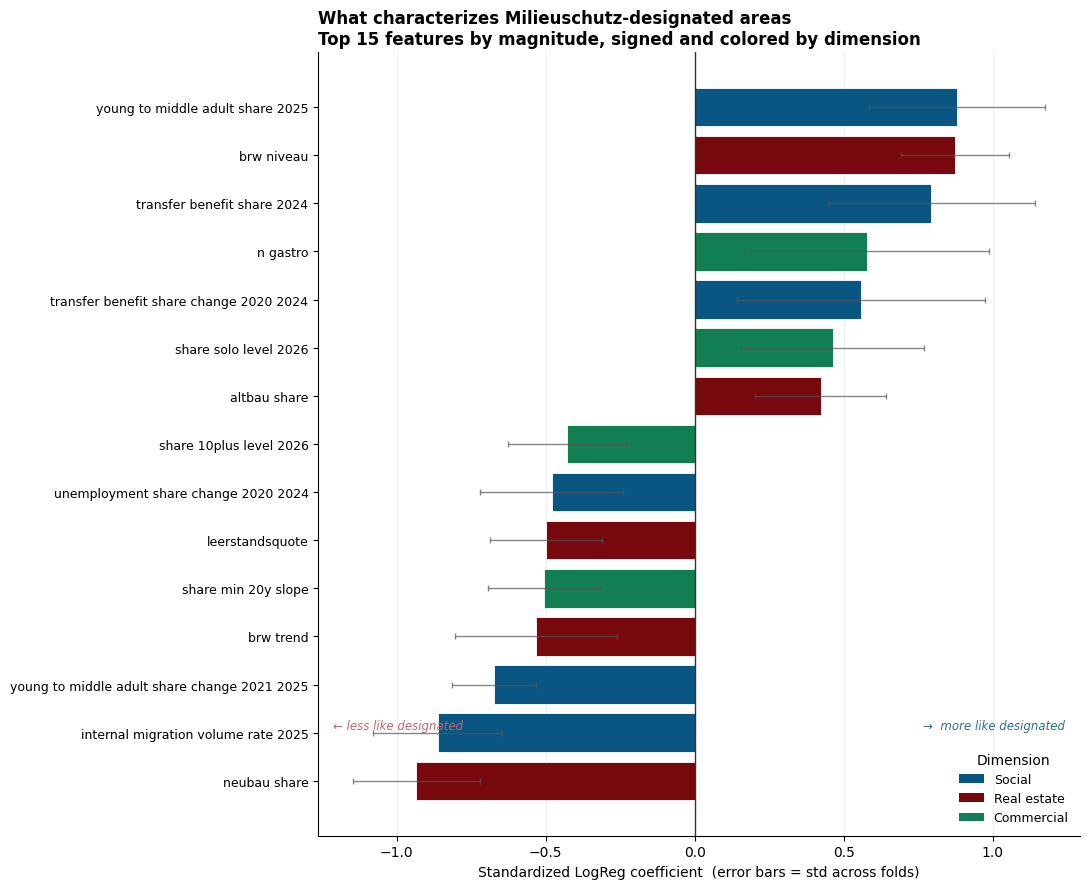

In [15]:
# Plot: LogReg coefficients — magnitude, direction, dimension, stability
TOP_N = 15
plot_df = coef_table.copy()
plot_df["dim"] = plot_df["feature"].str[:3]
plot_df = plot_df.reindex(plot_df["coef_all"].abs().sort_values(ascending=False).index)
plot_df = plot_df.head(TOP_N)
plot_df = plot_df.sort_values("coef_all", ascending=True).reset_index(drop=True)

palette = {"soc": "#095682", "re_": "#77080D", "com": "#117F53"}
labels  = {"soc": "Social", "re_": "Real estate", "com": "Commercial"}
colors  = plot_df["dim"].map(palette)

def pretty(f):
    for p in ("soc_", "re_", "com_"):
        if f.startswith(p):
            f = f[len(p):]
    return f.replace("_", " ")

ylabels = plot_df["feature"].apply(pretty)

fig, ax = plt.subplots(figsize=(11, 9))
y = np.arange(len(plot_df))
ax.barh(y, plot_df["coef_all"], xerr=plot_df["coef_std_fold"], color=colors,
        edgecolor="white", linewidth=0.6,
        error_kw=dict(ecolor="#555555", lw=1, capsize=2.5, alpha=0.7))
ax.axvline(0, color="#333333", lw=1)
ax.set_yticks(y); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel("Standardized LogReg coefficient  (error bars = std across folds)", fontsize=10)
ax.set_title("What characterizes Milieuschutz-designated areas\n"
             f"Top {TOP_N} features by magnitude, signed and colored by dimension",
             fontsize=12, fontweight="bold", loc="left")
ax.text(0.98, 1.01, "\u2192  more like designated", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=8.5, color="#2A6F97", style="italic", clip_on=False)
ax.text(0.02, 1.01, "\u2190 less like designated", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=8.5, color="#C1666B", style="italic", clip_on=False)
legend = [Patch(facecolor=palette[k], label=labels[k]) for k in ["soc", "re_", "com"]]
ax.legend(handles=legend, loc="lower right", frameon=False, fontsize=9, title="Dimension")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../../plots/logreg_coefficients.png", dpi=200, bbox_inches="tight")  # adjust path
plt.show()

## Plot discussion 

The chart shows the 15 strongest predictors of Milieuschutz designation, measured by standardized logistic-regression coefficients and colored by dimension (social, real estate, commercial). 

Features above the zero line make an area statistically more similar to a designated one, while those below make it less similar; error bars show coefficient stability across the five cross-validation folds. The strongest positive signals are social and real-estate features — a high share of young-to-middle adults, high land values (BRW niveau), and a high transfer-benefit share — describing the established profile of already-designated areas. 

The strongest negative signals point the other way: a high share of new construction, strong in-migration dynamics, and rising land-value trends all characterize areas that are not designated. This level-versus-change divergence is central to the early-warning framing, since areas showing upward movement rather than an established state are precisely those the designation label does not yet capture.